In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from torchvision import transforms
from torchvision import models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [2]:

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"{device}")

cpu


In [3]:
CLASS_NAMES = [
    "asteroid",
    "black_hole",
    "earth",
    "galaxy",
    "jupiter",
    "mars",
    "mercury",
    "neptune",
    "pluto",
    "saturn",
    "uranus",
    "venus"
]

In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
model = models.resnet18(weights=None)

model.fc = torch.nn.Linear(
    model.fc.in_features,
    len(CLASS_NAMES)
)

MODEL_PATH = Path("../models/resnet18_transfer.pth")

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.to(device)

model.eval()

print("ResNet18 Loaded Successfully!")

ResNet18 Loaded Successfully!


In [6]:
IMAGE_PATH = Path(
    "../datasets/raw/astro_dataset_maxia/test/galaxy/galaxy_024.jpg"
)

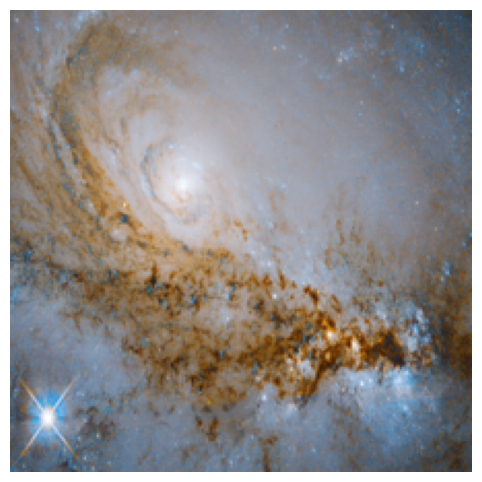

In [24]:
image = Image.open(
    IMAGE_PATH
).convert("RGB")

image = image.resize((224, 224))

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.show()

In [25]:
input_tensor = transform(image)
input_tensor = input_tensor.unsqueeze(0)
input_tensor = input_tensor.to(device)

In [26]:
with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

print("Prediction :", CLASS_NAMES[prediction.item()])
print(f"Confidence : {confidence.item()*100:.2f}%")

Prediction : galaxy
Confidence : 91.90%


In [27]:
target_layers = [model.layer4[-1]]
print(target_layers)

[BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
)]


In [28]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [29]:
targets = [
    ClassifierOutputTarget(
        prediction.item()
    )
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

In [30]:
print("rgb_image shape:", rgb_image.shape)
print("rgb_image dtype:", rgb_image.dtype)
print("rgb_image min/max:", rgb_image.min(), rgb_image.max())

print("grayscale_cam shape:", grayscale_cam.shape)
print("grayscale_cam dtype:", grayscale_cam.dtype)
print("grayscale_cam min/max:", grayscale_cam.min(), grayscale_cam.max())

rgb_image shape: (530, 750, 3)
rgb_image dtype: float32
rgb_image min/max: 0.0 1.0
grayscale_cam shape: (224, 224)
grayscale_cam dtype: float32
grayscale_cam min/max: 0.0 0.9999999


In [31]:
rgb_image = np.array(image).astype(np.float32)
rgb_image = rgb_image / 255.0

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True,
    image_weight=0.5
)

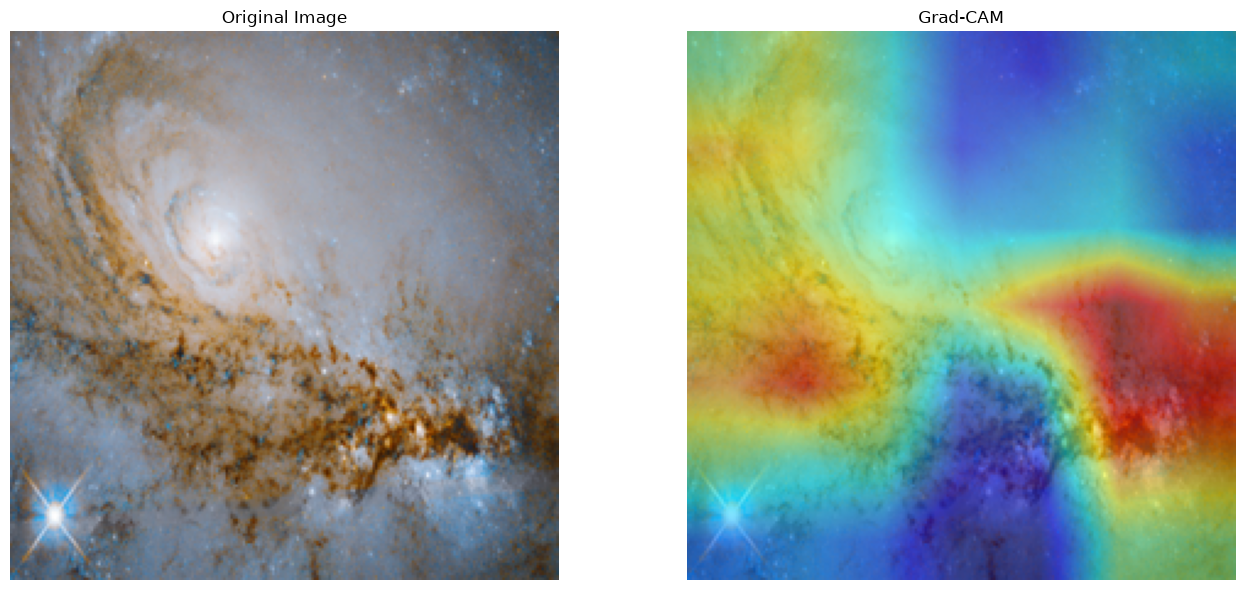

In [32]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
print("=" * 50)
print("Grad-CAM Explanation")
print("=" * 50)
print(f"Predicted Class : {CLASS_NAMES[prediction.item()]}")
print(f"Confidence      : {confidence.item()*100:.2f}%")
print("=" * 50)
print("The highlighted regions represent")
print("the parts of the image that")
print("contributed the most to the")
print("model's prediction.")
print("=" * 50)

Grad-CAM Explanation
Predicted Class : galaxy
Confidence      : 91.90%
The highlighted regions represent
the parts of the image that
contributed the most to the
model's prediction.
